This document analyzes the dataset logged by CARLA's system. The metrics to be measured are the following: 
1. **Reaction Time**
    - This is from the time the alert was sent until the time the driver made an action. This will help the researches know the appropriate time to give an alert. 
2. **Completion Time**
    - This measures the duration of the whole violation. From the alert being triggered until the speeding gets resolved. 
3. **Ignored Alert** 
    - This checks whether the driver made an action to the alert or ignored it. This will be used to prove the effectiveness of providing an alert to decrease speed.
4. **Speed Change**
    - This checks the speed. 
5. **Alert Effectiveness**
    - This computes for the number of resolved speeding violations, where the rider either *reduced throttle* or *brakes* which is then divided by all violations. (resolved/all violations) 

*Note: An action made by the driver can be either a release of the throttle or pressing on the brakes.* 

In [305]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import chi2_contingency
from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel
from scipy.stats import chi2_contingency
import matplotlib.patches as mpatches


In [196]:
df = pd.read_csv("cleaned_Sim.csv")

df.head()


,timestamp,participant_no,phase,scenario,speed_kmh,event,details,speed_limit,Location_X,Location_Y,overspeed,reduce_throttle,resolved,event_id,nearest_idx,distance_sq,on_route
0,1.771924e+09,17,4,WEBSOCKET,0.71,WS_SEND,"{""phase"": 4, ""speed"": 0.71, ""speed_limit"": 30,...",30.0,NaN,NaN,False,False,False,0,-1,inf,False
1,1.771924e+09,17,4,WEBSOCKET,0.71,WS_SEND,"{""phase"": 4, ""speed"": 0.71, ""speed_limit"": 30,...",30.0,NaN,NaN,False,False,False,0,-1,inf,False
2,1.771924e+09,17,4,WEBSOCKET,0.71,WS_SEND,"{""phase"": 4, ""speed"": 0.71, ""speed_limit"": 30,...",30.0,NaN,NaN,False,False,False,0,-1,inf,False
3,1.771924e+09,17,4,WEBSOCKET,1.17,WS_SEND,"{""phase"": 4, ""speed"": 1.17, ""speed_limit"": 30,...",30.0,NaN,NaN,False,False,False,0,-1,inf,False
4,1.771924e+09,17,4,WEBSOCKET,1.19,WS_SEND,"{""phase"": 4, ""speed"": 1.19, ""speed_limit"": 30,...",30.0,NaN,NaN,False,False,False,0,-1,inf,False


In [197]:
df.columns

Index(['timestamp', 'participant_no', 'phase', 'scenario', 'speed_kmh',
       'event', 'details', 'speed_limit', 'Location_X', 'Location_Y',
       'overspeed', 'reduce_throttle', 'resolved', 'event_id', 'nearest_idx',
       'distance_sq', 'on_route'],
      dtype='object')

In [198]:
df["scenario"].unique()

array(['WEBSOCKET', 'TRAFFIC_LIGHT', 'SPEED_LIMIT', 'STOP'], dtype=object)

In [199]:
df["details"].str.contains("TrafficLight", na=False).sum()

276

In [200]:
df.loc[
    (df["event_id"]==45),
    ["speed_kmh", "scenario", "speed_limit", "details", "event_id"]
]

,speed_kmh,scenario,speed_limit,details,event_id
77952,37.25,WEBSOCKET,30.0,"{""phase"": 3, ""speed"": 37.25, ""speed_limit"": 30...",45
77953,37.55,WEBSOCKET,30.0,"{""phase"": 3, ""speed"": 37.55, ""speed_limit"": 30...",45
77954,38.12,WEBSOCKET,30.0,"{""phase"": 3, ""speed"": 38.12, ""speed_limit"": 30...",45
77955,38.12,WEBSOCKET,30.0,"{""phase"": 3, ""speed"": 38.12, ""speed_limit"": 30...",45
77956,38.12,WEBSOCKET,30.0,"{""phase"": 3, ""speed"": 38.12, ""speed_limit"": 30...",45
77957,38.52,WEBSOCKET,30.0,"{""phase"": 3, ""speed"": 38.52, ""speed_limit"": 30...",45
77958,39.81,WEBSOCKET,30.0,"{""phase"": 3, ""speed"": 39.81, ""speed_limit"": 30...",45
77959,40.03,WEBSOCKET,30.0,"{""phase"": 3, ""speed"": 40.03, ""speed_limit"": 30...",45
77960,40.03,WEBSOCKET,30.0,"{""phase"": 3, ""speed"": 40.03, ""speed_limit"": 30...",45
77961,40.03,WEBSOCKET,30.0,"{""phase"": 3, ""speed"": 40.03, ""speed_limit"": 30...",45


In [201]:
df["event"].unique()

array(['WS_SEND', 'YELLOW_LIGHT_PASS', 'REACTION', 'SPEED_VIOLATION',
       'RED_LIGHT_VIOLATION', 'PHASE_STOP'], dtype=object)

In [202]:
df.loc[
    (df["participant_no"] == 5) & (df["event"]=="RED_LIGHT_VIOLATION"),
    ["participant_no", "phase", "speed_kmh", "scenario", "details", "event_id"]
]

,participant_no,phase,speed_kmh,scenario,details,event_id
211449,5,4,19.74,TRAFFIC_LIGHT,TrafficLight Violation at Location(x=-20.03606...,0
212071,5,4,21.02,TRAFFIC_LIGHT,TrafficLight Violation at Location(x=134.17388...,0
212799,5,4,8.15,TRAFFIC_LIGHT,TrafficLight Violation at Location(x=230.82778...,0
213824,5,4,7.24,TRAFFIC_LIGHT,TrafficLight Violation at Location(x=22.778585...,0
215284,5,4,7.86,TRAFFIC_LIGHT,TrafficLight Violation at Location(x=-144.5323...,0
215430,5,4,26.32,TRAFFIC_LIGHT,TrafficLight Violation at Location(x=-131.9122...,0
215440,5,4,29.22,TRAFFIC_LIGHT,TrafficLight Violation at Location(x=-128.6030...,0
215624,5,4,7.44,TRAFFIC_LIGHT,TrafficLight Violation at Location(x=-101.6513...,0
216504,5,4,16.65,TRAFFIC_LIGHT,TrafficLight Violation at Location(x=-19.43998...,0
216890,5,1,10.07,TRAFFIC_LIGHT,TrafficLight Violation at Location(x=-61.08915...,0


In [203]:
df.loc[df["speed_limit"] == 60, "event_id"].unique()

array([  5,   0,  29,  51, 122, 136, 183, 235, 250, 270, 289, 290, 291,
       292, 301, 332, 412, 422, 432, 522, 532])

## Metrics Computation & Analysis

In [204]:
df_Metrics = df.copy()

### Reaction Time

*action=REDUCE_THROTTLE* is a signal that the driver released yung tapak niya sa pedal. 

In [205]:
df.loc[
    df["event_id"].isin([9]),
    ["phase","speed_kmh", "scenario", "speed_limit", "details", "event_id"]
]

,phase,speed_kmh,scenario,speed_limit,details,event_id
15607,2,40.00,SPEED_LIMIT,NaN,action=REDUCE_THROTTLE|time=0.52s|control={'th...,9
15608,2,40.10,SPEED_LIMIT,30.0,Speed 40.10 km/h > limit 30.00 km/h at Locatio...,9
15609,2,36.87,SPEED_LIMIT,NaN,action=VIOLATION_RESOLVED|time=0.99s|reaction_...,9


In [206]:
df_Metrics["carla_reaction_time"] = (
    df_Metrics.loc[df_Metrics["scenario"] == "SPEED_LIMIT", "details"]
    .str.extract(r"action=REDUCE_THROTTLE\|time=(\d+\.\d+)s")
    .astype(float)
)

In [207]:
carla_reactions = df_Metrics.loc[
    df_Metrics["carla_reaction_time"].notna(),
    ["event_id", "carla_reaction_time"]
]

In [208]:
display(carla_reactions.head(5))

,event_id,carla_reaction_time
767,1,0.76
5496,2,1.86
6252,3,0.76
7122,4,0.21
15598,7,1.92


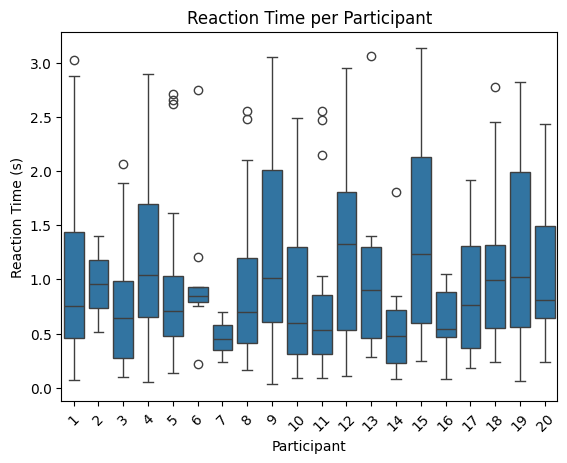

In [296]:
sns.boxplot(
    data=df_Metrics,
    x="participant_no",
    y="carla_reaction_time"
)

plt.xlabel("Participant")
plt.ylabel("Reaction Time (s)")
plt.title("Reaction Time per Participant")
plt.xticks(rotation=45)
plt.show()

*Note: in the cases of NaN values: at times the rider is just above the speeding threshold, the system in CARLA might not have detected enough throttle release. Therefore, in the subtracting the action to the start becomes not applicable.*

### Completion Time

In [209]:
df_Metrics["carla_completion_time"] = df_Metrics["details"].str.extract(
    r"action=VIOLATION_RESOLVED\|time=(\d+\.\d+)s"
).astype(float)

In [210]:
carla_complete = df_Metrics.loc[
    df_Metrics["carla_completion_time"].notna(),
    ["event_id", "carla_completion_time"]
]

In [211]:
display(carla_complete.tail(10))

,event_id,carla_completion_time
348702,0,0.15
349962,534,0.49
350409,535,3.98
351085,536,0.22
351980,537,2.39
352149,538,0.29
352709,539,1.77
353765,540,3.45
355066,541,1.91
356023,542,1.77


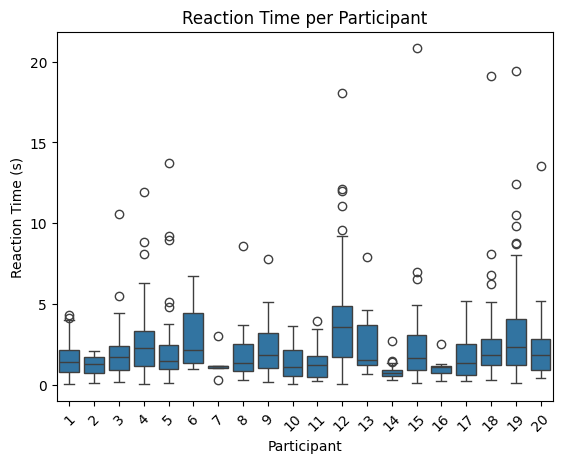

In [297]:
sns.boxplot(
    data=df_Metrics,
    x="participant_no",
    y="carla_completion_time"
)

plt.xlabel("Participant")
plt.ylabel("Reaction Time (s)")
plt.title("Reaction Time per Participant")
plt.xticks(rotation=45)
plt.show()

### Ignored Alert

In [212]:
df_Metrics["alert_ignored"] = (df_Metrics["carla_reaction_time"] >= 2.5).fillna(0).astype(int)

In [213]:
ignore = df_Metrics.loc[
    df_Metrics["carla_reaction_time"].notna(),  # only rows with reaction time
    ["event_id", "carla_reaction_time", "alert_ignored"]  # columns to display
]

ignore.tail(10)

,event_id,carla_reaction_time,alert_ignored
348692,532,0.24,0
348698,533,0.57,0
349958,534,0.37,0
350380,535,2.55,1
351948,537,0.82,0
352144,538,0.12,0
352690,539,0.89,0
353744,540,2.47,0
355047,541,1.03,0
356003,542,0.87,0


### Alert Effectiveness

In [214]:
speedingCount = df_Metrics["details"].str.contains("VIOLATION_RESOLVED", na=False).sum() # dapat not ignored to
unignored = (carla_reactions["carla_reaction_time"] < 2.5).sum()
ignored = (carla_reactions["carla_reaction_time"] >= 2.5).sum()
valid_reactions = (carla_reactions["carla_reaction_time"]).notna().sum()
valid_complete = (carla_complete["carla_completion_time"].notna().sum())

In [215]:
total_effective = unignored/speedingCount

In [216]:
print("Unignored Count: ", unignored)
print("Ignored Count: ", ignored)
print("Supposed Total events: ", unignored + ignored)
print("Reaction Time: ", valid_reactions)
print("Completion Time: ", valid_complete)
print("Total resolved violations: ", speedingCount)
print(f"Effectiveness: {total_effective*100:.4f}%")

Unignored Count:  435
Ignored Count:  29
Supposed Total events:  464
Reaction Time:  464
Completion Time:  601
Total resolved violations:  601
Effectiveness: 72.3794%


In [217]:
ignored_result=(ignored / df_Metrics["event_id"].nunique())

In [218]:
print(f"Ignored alerts: {ignored_result* 100:.4f}%")

Ignored alerts: 5.3407%


In [219]:
summary_table = pd.DataFrame({
    "Mean": [
        carla_complete["carla_completion_time"].mean(),
        carla_reactions["carla_reaction_time"].mean()
    ],
    "Median": [
        carla_complete["carla_completion_time"].median(),
        carla_reactions["carla_reaction_time"].median()
    ],
    "Std Dev": [
        carla_complete["carla_completion_time"].std(),
        carla_reactions["carla_reaction_time"].std()
    ]
},
index=[
    "Completion Time",
    "Reaction Time"
])

print(summary_table)

                     Mean  Median   Std Dev
Completion Time  2.499850   1.710  2.596440
Reaction Time    1.061595   0.835  0.766071


## Alert-Phase Analysis

| Metric                     | Why                             |
| -------------------------- | ------------------------------- |
| Mean Reaction Time         | how quickly riders respond      |
| SD Reaction Time           | variability                     |
| Mean Completion Time       | how fast violation is corrected |
| Ignored Alert Rate         | how often alerts are ignored    |



In [220]:
results = []

for phase, df_phase in df_Metrics.groupby("phase"):

    n_events = df_phase["carla_reaction_time"].notna().sum()

    reactions = df_phase["carla_reaction_time"].dropna()
    mean_reaction = reactions.mean()
    median_reactions = reactions.median()
    sd_reaction = reactions.std()

    results.append({
        "Phase": phase,
        "n_events": n_events,
        "Mean ReactionT": mean_reaction,
        "Median ReactionT": median_reactions,
        "SD ReactionT": sd_reaction
    })

metrics_table = pd.DataFrame(results).sort_values("Phase")
display(metrics_table)

,Phase,n_events,Mean ReactionT,Median ReactionT,SD ReactionT
0,1,112,1.179821,1.04,0.776053
1,2,90,1.145333,0.94,0.821778
2,3,146,0.964932,0.75,0.747430
3,4,116,1.004138,0.78,0.721209


In [221]:
results = []

for phase, df_phase in df_Metrics.groupby("phase"):

    n_events = df_phase["details"].str.contains("VIOLATION_RESOLVED", na=False).sum()

    complete = df_phase["carla_completion_time"].dropna()
    mean_complete = complete.mean()
    sd_complete = complete.std()

    total_violations = n_events
    unignored = (df_phase["carla_reaction_time"] < 2.5).sum()

    ignored_percent = ((total_violations - unignored) / total_violations) * 100 if total_violations > 0 else 0
    effectiveness = (unignored / total_violations)*100 if total_violations > 0 else 0

    results.append({
        "Phase": phase,
        "n_events": n_events,
        "Mean Complete": mean_complete,
        "STD Complete" : sd_complete,
        "Ignored %": ignored_percent,
        "Effectiveness": effectiveness
    })

metrics_table = pd.DataFrame(results).sort_values("Phase")
display(metrics_table)

,Phase,n_events,Mean Complete,STD Complete,Ignored %,Effectiveness
0,1,156,2.731410,2.325275,32.692308,67.307692
1,2,122,2.893689,3.308951,32.786885,67.213115
2,3,182,2.117088,2.194470,24.725275,75.274725
3,4,141,2.396950,2.611643,21.276596,78.723404


## new changes 

### Baseline
- compute individually for the speeding violations
- compute reaction time and completion time - joke di to need kasi walang alerts 

In [223]:
df_phase1 = df_Metrics[df_Metrics["phase"] == 1]

In [224]:
violations = df_phase1["event"].str.contains("SPEED", na=False)
speed_counts = (
    df_phase1[violations]
    .groupby("participant_no")
    .size()
)
speed_counts = speed_counts.reindex(range(1, 21), fill_value=0)

In [225]:
display(speed_counts)

participant_no
1     21
2      2
3     15
4     11
5      7
6      2
7      1
8      3
9     14
10     4
11     7
12    20
13     1
14     6
15    11
16     2
17     2
18     7
19    16
20     4
dtype: int64

### Audio Only

In [227]:
df_phase2 = df_Metrics[df_Metrics["phase"] == 2]

In [228]:
violations = df_phase2["event"].str.contains("SPEED", na=False)
speed_counts2 = (
    df_phase2[violations]
    .groupby("participant_no")
    .size()
)
speed_counts2 = speed_counts2.reindex(range(1, 21), fill_value=0)

In [229]:
display(speed_counts2)

participant_no
1      3
2      1
3      2
4      8
5      8
6      3
7      1
8     13
9     10
10     9
11     4
12    18
13     4
14     2
15    12
16     0
17     3
18     4
19    13
20     4
dtype: int64

### Haptic Only

In [233]:
df_phase3 = df_Metrics[df_Metrics["phase"] == 3]

In [234]:
violations = df_phase3["event"].str.contains("SPEED", na=False)
speed_counts3 = (
    df_phase3[violations]
    .groupby("participant_no")
    .size()
)
speed_counts3 = speed_counts3.reindex(range(1, 21), fill_value=0)

In [235]:
print(speed_counts3)

participant_no
1      8
2      1
3      7
4     20
5      5
6      3
7      2
8      0
9     21
10    15
11     9
12    25
13     3
14     4
15    18
16     1
17     2
18     9
19    23
20     6
dtype: int64


### Combined

In [240]:
df_phase4 = df_Metrics[df_Metrics["phase"] == 4]
df_phase4.columns

Index(['timestamp', 'participant_no', 'phase', 'scenario', 'speed_kmh',
       'event', 'details', 'speed_limit', 'Location_X', 'Location_Y',
       'overspeed', 'reduce_throttle', 'resolved', 'event_id', 'nearest_idx',
       'distance_sq', 'on_route', 'carla_reaction_time',
       'carla_completion_time', 'alert_ignored'],
      dtype='object')

In [241]:
violations = df_phase4["event"].str.contains("SPEED", na=False)
speed_counts4 = (
    df_phase4[violations]
    .groupby("participant_no")
    .size()
)
speed_counts4 = speed_counts4.reindex(range(1, 21), fill_value=0)

In [242]:
display(speed_counts4)

participant_no
1     13
2      0
3     12
4     18
5      9
6      5
7      1
8      8
9      0
10     2
11     5
12    14
13     3
14     5
15     0
16     5
17     3
18    17
19    17
20     5
dtype: int64

In [248]:
df_Metrics["event"].unique()

array(['WS_SEND', 'YELLOW_LIGHT_PASS', 'REACTION', 'SPEED_VIOLATION',
       'RED_LIGHT_VIOLATION', 'PHASE_STOP'], dtype=object)

In [249]:
mostViolation = (
    df_Metrics[df_Metrics["event"] == "SPEED_VIOLATION"]
    .groupby("phase")
    .size()
)

display(mostViolation)

phase
1    156
2    122
3    182
4    142
dtype: int64

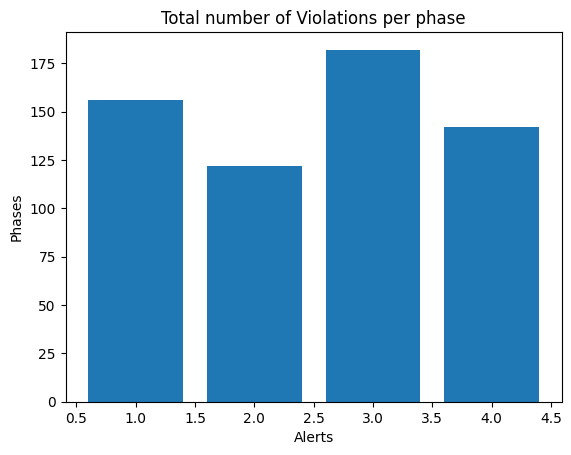

In [250]:
plt.bar(mostViolation.index, mostViolation.values)

plt.xlabel("Alerts")
plt.ylabel("Phases")
plt.title("Total number of Violations per phase")

plt.show()

In [312]:
def get_ignored_counts(df):
    mask = df["alert_ignored"] == 1
    return (
        df[mask]
        .groupby("participant_no")
        .size()
        .reindex(range(1, 21), fill_value=0)
    )

ignored_counts2 = get_ignored_counts(df_phase2)  # Audio
ignored_counts3 = get_ignored_counts(df_phase3)  # Haptic
ignored_counts4 = get_ignored_counts(df_phase4)  # Combined

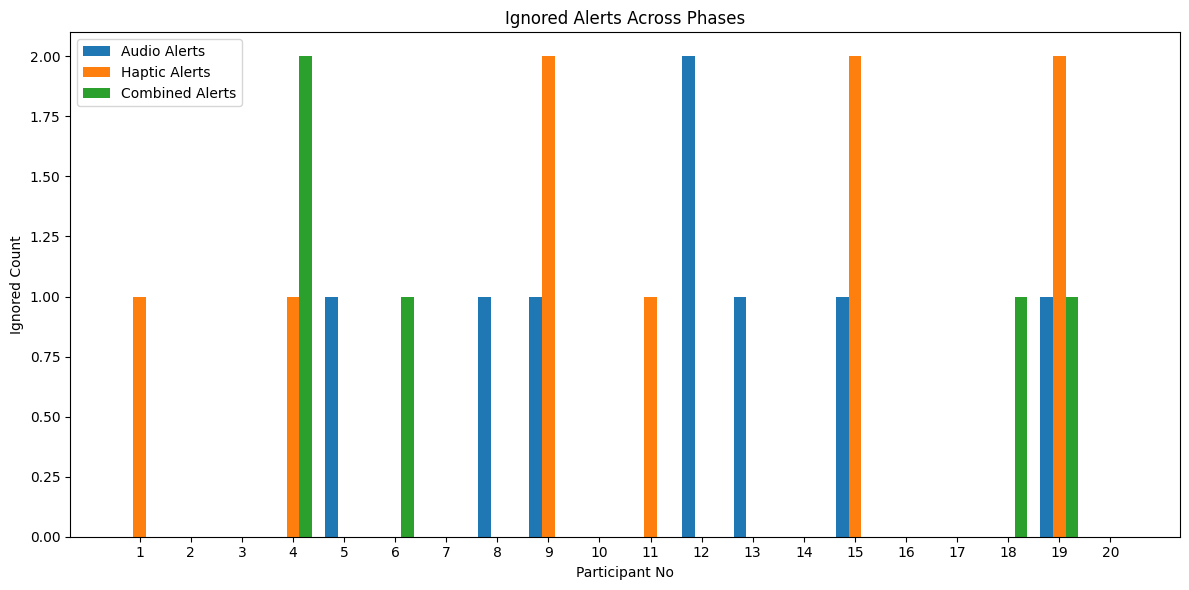

In [313]:
participants = np.arange(1, 21)
width = 0.25  # 3 groups → slightly wider than 4-case

plt.figure(figsize=(12, 6))

plt.bar(participants - width, ignored_counts2.values,
        width=width, label="Audio Alerts")

plt.bar(participants, ignored_counts3.values,
        width=width, label="Haptic Alerts")

plt.bar(participants + width, ignored_counts4.values,
        width=width, label="Combined Alerts")

plt.xlabel("Participant No")
plt.ylabel("Ignored Count")
plt.title("Ignored Alerts Across Phases")

plt.xticks(participants)
plt.legend()

plt.tight_layout()
plt.show()

In [314]:
def get_speed_counts(df):
    mask = df["event"].str.contains("SPEED", na=False)
    return (
        df[mask]
        .groupby("participant_no")
        .size()
        .reindex(range(1, 21), fill_value=0)
    )

speed_counts1 = get_speed_counts(df_phase1)  # Baseline
speed_counts2 = get_speed_counts(df_phase2)  # Audio
speed_counts3 = get_speed_counts(df_phase3)  # Haptic
speed_counts4 = get_speed_counts(df_phase4)  # Combined

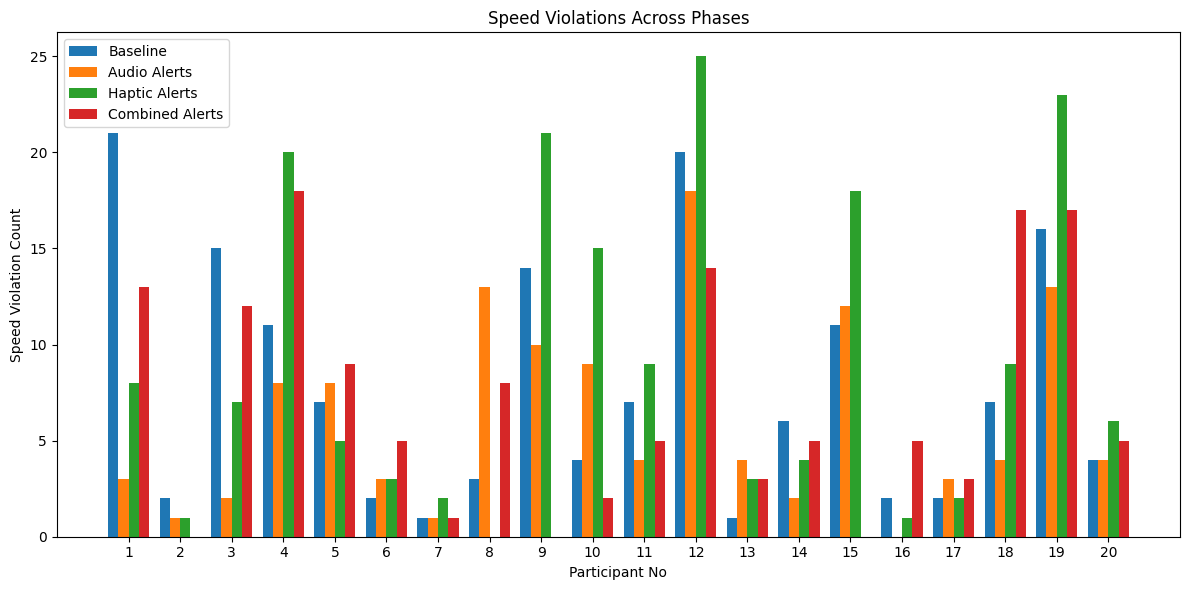

In [315]:
participants = np.arange(1, 21)
width = 0.2  # 4 bars → smaller width

plt.figure(figsize=(12, 6))

plt.bar(participants - 1.5*width, speed_counts1.values,
        width=width, label="Baseline")

plt.bar(participants - 0.5*width, speed_counts2.values,
        width=width, label="Audio Alerts")

plt.bar(participants + 0.5*width, speed_counts3.values,
        width=width, label="Haptic Alerts")

plt.bar(participants + 1.5*width, speed_counts4.values,
        width=width, label="Combined Alerts")

plt.xlabel("Participant No")
plt.ylabel("Speed Violation Count")
plt.title("Speed Violations Across Phases")

plt.xticks(participants)
plt.legend()

plt.tight_layout()
plt.show()

## other parts na 

In [252]:
alerts = df_Metrics[df_Metrics["carla_reaction_time"].notna()]

ignored_alerts = (alerts["carla_reaction_time"] >= 2.5).sum()

overall_ignored_percent = ignored_alerts / len(alerts) * 100

print(f"Overall ignored alerts: {overall_ignored_percent:.2f}%")

Overall ignored alerts: 6.25%


In [253]:
# collapse to one row per event
alerts = df_Metrics.groupby("event_id").agg({
    "phase": "first",           # each event belongs to one phase
    "alert_ignored": "max"      # if any frame was ignored, mark the event as ignored
}).reset_index()

# now build the correct contingency table
contingency_table = pd.crosstab(alerts["phase"], alerts["alert_ignored"])
print(contingency_table)

alert_ignored    0  1
phase                
1              105  7
2              111  8
3              163  9
4              135  5


## STOPLIGHT

In [254]:
results = []

for phase, df_phase in df.groupby("phase"):

    # total traffic lights encountered
    lights_encountered = df_phase["scenario"].eq("TRAFFIC_LIGHT").sum()

    # red light violations
    violations = df_phase["event"].str.contains("RED_LIGHT_VIOLATION", na=False).sum()

    # compliance rate
    compliance_rate = ((lights_encountered - violations) / lights_encountered) if lights_encountered > 0 else 0

    results.append({
        "Phase": phase,
        "Traffic Lights Encountered": lights_encountered,
        "Violations": violations,
        "Compliance Rate": compliance_rate
    })

traffic_table = pd.DataFrame(results).sort_values("Phase")

display(traffic_table)

,Phase,Traffic Lights Encountered,Violations,Compliance Rate
0,1,108,56,0.481481
1,2,125,55,0.560000
2,3,177,86,0.514124
3,4,167,79,0.526946


In [255]:
# ground truth encounters based on route design
route_lights = {
    1: 7,
    2: 7,
    3: 11,
    4: 8
}

participants = 20

traffic_table["Traffic Lights Encountered"] = (
    traffic_table["Phase"].map(route_lights) * participants
)

# recompute compliance
traffic_table["Compliance Rate"] = (
    (traffic_table["Traffic Lights Encountered"] - traffic_table["Violations"])
    / traffic_table["Traffic Lights Encountered"]
)

display(traffic_table)

,Phase,Traffic Lights Encountered,Violations,Compliance Rate
0,1,140,56,0.600000
1,2,140,55,0.607143
2,3,220,86,0.609091
3,4,160,79,0.506250


In [301]:
violations_light = df_phase1["event"].str.contains("RED_LIGHT_VIOLATION", na=False)

light_counts1 = (
    df_phase1[violations_light]
    .groupby("participant_no")
    .size()
).reindex(range(1, 21), fill_value=0)

violations_light2 = df_phase2["event"].str.contains("RED_LIGHT_VIOLATION", na=False)

light_counts2 = (
    df_phase2[violations_light2]
    .groupby("participant_no")
    .size()
).reindex(range(1, 21), fill_value=0)

violations_light3 = df_phase3["event"].str.contains("RED_LIGHT_VIOLATION", na=False)

light_counts3 = (
    df_phase3[violations_light3]
    .groupby("participant_no")
    .size()
).reindex(range(1, 21), fill_value=0)

violations_light4 = df_phase4["event"].str.contains("RED_LIGHT_VIOLATION", na=False)

light_counts4 = (
    df_phase4[violations_light4]
    .groupby("participant_no")
    .size()
).reindex(range(1, 21), fill_value=0)

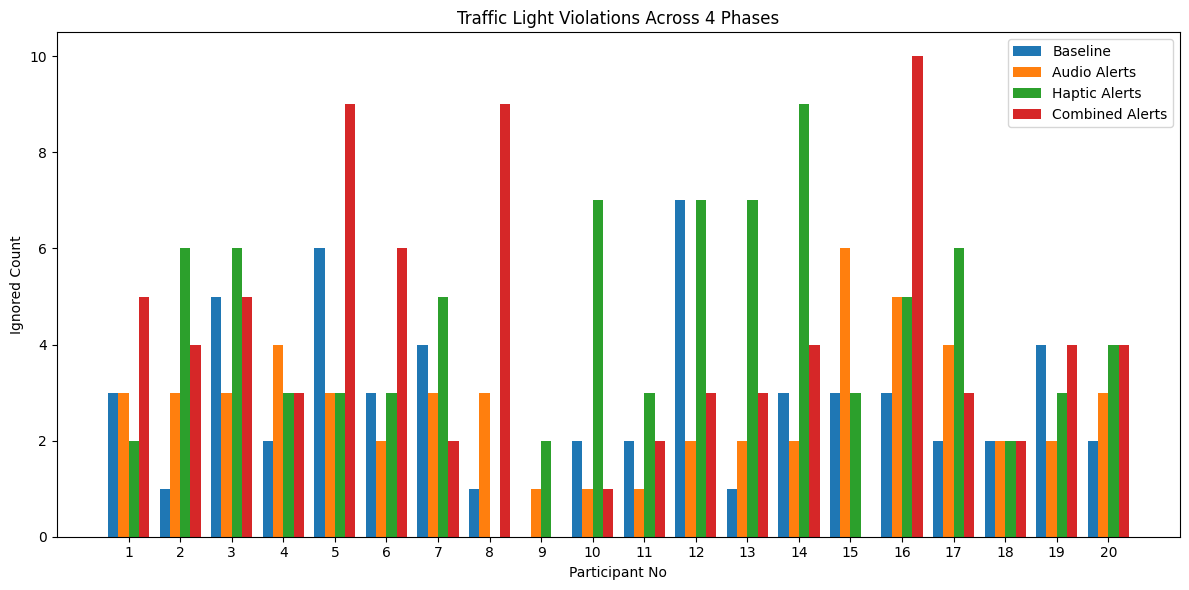

In [304]:
participants = np.arange(1, 21)
width = 0.2  # smaller width since we now have 4 bars

plt.figure(figsize=(12, 6))

plt.bar(participants - 1.5*width, light_counts1.values, 
        width=width, label="Baseline")

plt.bar(participants - 0.5*width, light_counts2.values, 
        width=width, label="Audio Alerts")

plt.bar(participants + 0.5*width, light_counts3.values, 
        width=width, label="Haptic Alerts")

plt.bar(participants + 1.5*width, light_counts4.values, 
        width=width, label="Combined Alerts")

plt.xlabel("Participant No")
plt.ylabel("Ignored Count")
plt.title("Traffic Light Violations Across 4 Phases")

plt.xticks(participants)
plt.legend()

plt.tight_layout()
plt.show()

In [306]:
def categorize_changes(baseline, other):
    return np.array([
        "increase" if o > b else "decrease" if o < b else "same"
        for b, o in zip(baseline, other)
    ])

cat_phase2 = categorize_changes(light_counts1.values, light_counts2.values)
cat_phase3 = categorize_changes(light_counts1.values, light_counts3.values)
cat_phase4 = categorize_changes(light_counts1.values, light_counts4.values)

In [307]:
from collections import Counter

def count_categories(cat_array):
    c = Counter(cat_array)
    return [c["increase"], c["decrease"], c["same"]]

counts_p2 = count_categories(cat_phase2)
counts_p3 = count_categories(cat_phase3)
counts_p4 = count_categories(cat_phase4)

In [308]:
contingency_table = np.array([
    counts_p2,
    counts_p3,
    counts_p4
])

print(contingency_table)

[[ 9  9  2]
 [12  4  4]
 [11  4  5]]


In [309]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:\n", expected)

Chi-square: 4.651403743315508
p-value: 0.3249704153117857
Degrees of freedom: 4
Expected frequencies:
 [[10.66666667  5.66666667  3.66666667]
 [10.66666667  5.66666667  3.66666667]
 [10.66666667  5.66666667  3.66666667]]


In [257]:
df_phase1.columns

Index(['timestamp', 'participant_no', 'phase', 'scenario', 'speed_kmh',
       'event', 'details', 'speed_limit', 'Location_X', 'Location_Y',
       'overspeed', 'reduce_throttle', 'resolved', 'event_id', 'nearest_idx',
       'distance_sq', 'on_route', 'carla_reaction_time',
       'carla_completion_time', 'alert_ignored'],
      dtype='object')

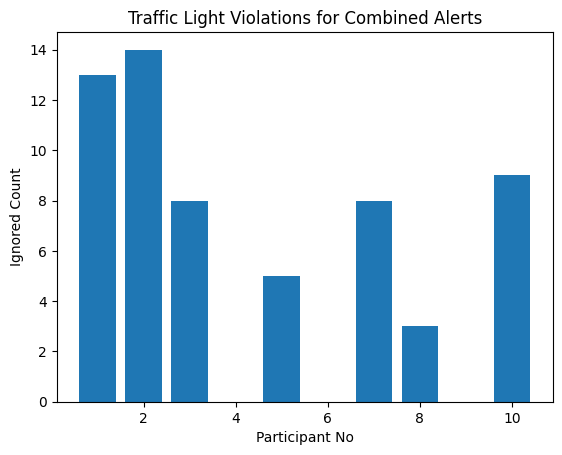

In [287]:
plt.bar(area1.index, area1.values)

plt.xlabel("Participant No")
plt.ylabel("Ignored Count")
plt.title("Traffic Light Violations for Combined Alerts")

plt.show()

In [275]:
df_phase1.loc[
    (df_phase1["nearest_idx"]==2) & 
    (df_phase1["scenario"]=="TRAFFIC_LIGHT")&
    (df_phase1["on_route"]==True),
    ["scenario", "Location_X", "Location_Y", "nearest_idx", "distance_sq", "on_route"]
].head(50)

,scenario,Location_X,Location_Y,nearest_idx,distance_sq,on_route
7125,TRAFFIC_LIGHT,-85.075447,113.654617,2,40.269578,True
15617,TRAFFIC_LIGHT,-87.377663,116.541153,2,17.616904,True
71443,TRAFFIC_LIGHT,-84.934715,113.734741,2,39.257732,True
97426,TRAFFIC_LIGHT,-84.587967,115.113686,2,24.045836,True
121982,TRAFFIC_LIGHT,-84.496178,116.443047,2,12.905751,True
122112,TRAFFIC_LIGHT,-84.581894,115.096466,2,24.219458,True
122151,TRAFFIC_LIGHT,-88.216942,117.368523,2,17.273387,True
149470,TRAFFIC_LIGHT,-84.502037,113.653152,2,40.530447,True
169914,TRAFFIC_LIGHT,-85.893326,113.718407,2,40.256442,True
216892,TRAFFIC_LIGHT,-84.582207,113.726540,2,39.530851,True


In [289]:
area2 = (
        df_phase2[
                (df_phase2["on_route"]==True)&
                (df_phase2["scenario"]=="TRAFFIC_LIGHT")]
        .groupby("nearest_idx")
        .size()
)
display(area2)

nearest_idx
1    12
2    12
3    10
4     5
5     4
8    10
9    13
dtype: int64

In [274]:
df_phase2.loc[
    (df_phase2["nearest_idx"]==6), #& 
    #(df_phase2["on_route"]==True),
    ["scenario", "Location_X", "Location_Y", "nearest_idx", "distance_sq", "on_route"]
].head(50)

,scenario,Location_X,Location_Y,nearest_idx,distance_sq,on_route
74228,SPEED_LIMIT,250.339890,-62.468338,6,10981.128878,False
75434,SPEED_LIMIT,128.215744,-76.089142,6,470.820176,False
141249,SPEED_LIMIT,242.440353,-32.075665,6,11719.965510,False
141252,SPEED_LIMIT,244.040878,-85.384636,6,9223.998192,False
226744,SPEED_LIMIT,126.542137,-73.274948,6,597.916729,False
254376,SPEED_LIMIT,242.947372,-29.399811,6,12106.384467,False
267897,SPEED_LIMIT,125.977196,-74.219444,6,601.224284,False
271758,SPEED_LIMIT,243.436768,-33.430996,6,11767.538860,False
271847,SPEED_LIMIT,244.542221,-66.796051,6,9651.784195,False
272826,SPEED_LIMIT,125.401665,-75.597969,6,599.082932,False


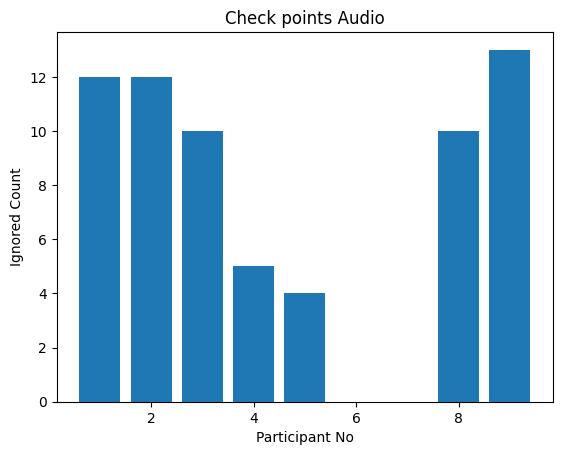

In [320]:
plt.bar(area2.index, area2.values)

plt.xlabel("Participant No")
plt.ylabel("Ignored Count")
plt.title("Check points Audio")

plt.show()

participant_no
1     2
2     6
3     6
4     3
5     3
6     3
7     5
8     0
9     2
10    7
11    3
12    7
13    7
14    9
15    3
16    5
17    6
18    2
19    3
20    4
dtype: int64


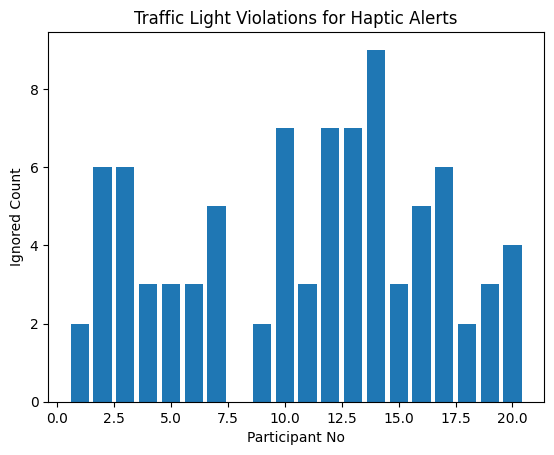

In [264]:
violations_light = df_phase3["event"].str.contains("RED_LIGHT_VIOLATION", na=False)

# count violations per participant
light_counts3 = (
    df_phase3[violations_light]       # filter rows
    .groupby("participant_no")       # group by participant
    .size()                          # count rows
)

light_counts3 = light_counts3.reindex(range(1, 21), fill_value=0)

print(light_counts3)

plt.bar(light_counts3.index, light_counts3.values)

plt.xlabel("Participant No")
plt.ylabel("Ignored Count")
plt.title("Traffic Light Violations for Haptic Alerts")

plt.show()

In [292]:
area3 = (
        df_phase3[
                (df_phase3["on_route"]==True)&
                (df_phase3["scenario"]=="TRAFFIC_LIGHT")]
        .groupby("nearest_idx")
        .size()
)
display(area3)

nearest_idx
1     13
3      5
4     16
5      2
9     11
11     7
13    11
15     8
16     3
17     8
18    11
dtype: int64

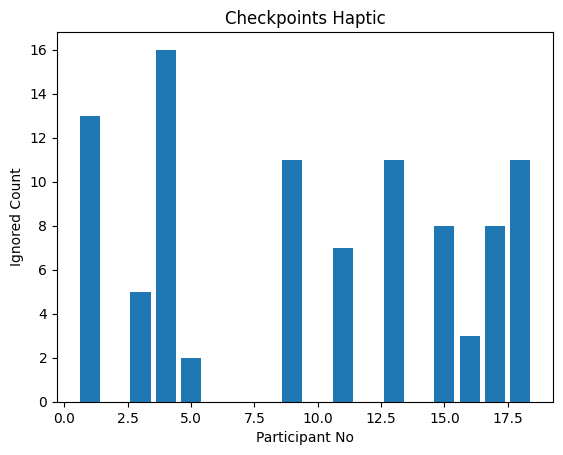

In [319]:
plt.bar(area3.index, area3.values)

plt.xlabel("Participant No")
plt.ylabel("Ignored Count")
plt.title("Checkpoints Haptic")

plt.show()

participant_no
1      5
2      4
3      5
4      3
5      9
6      6
7      2
8      9
9      0
10     1
11     2
12     3
13     3
14     4
15     0
16    10
17     3
18     2
19     4
20     4
dtype: int64


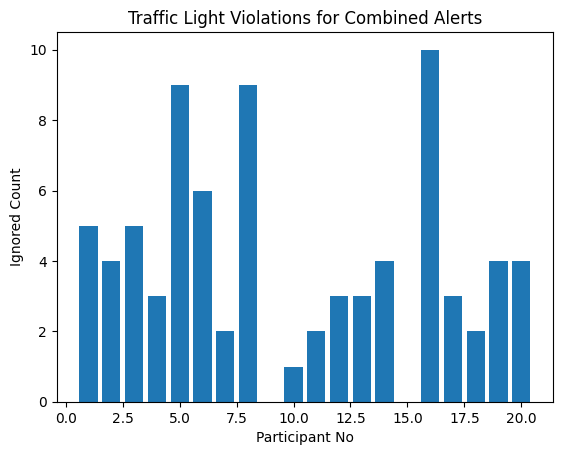

In [266]:
violations_light = df_phase4["event"].str.contains("RED_LIGHT_VIOLATION", na=False)

# count violations per participant
light_counts4 = (
    df_phase4[violations_light]       # filter rows
    .groupby("participant_no")       # group by participant
    .size()                          # count rows
)

light_counts4 = light_counts4.reindex(range(1, 21), fill_value=0)

print(light_counts4)

plt.bar(light_counts4.index, light_counts4.values)

plt.xlabel("Participant No")
plt.ylabel("Ignored Count")
plt.title("Traffic Light Violations for Combined Alerts")

plt.show()

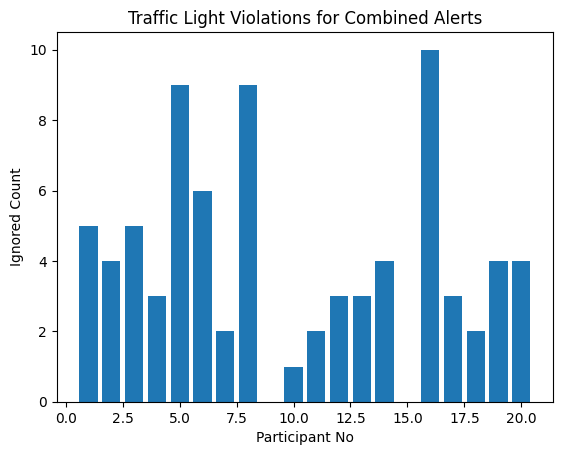

In [267]:
plt.bar(light_counts4.index, light_counts4.values)

plt.xlabel("Participant No")
plt.ylabel("Ignored Count")
plt.title("Traffic Light Violations for Combined Alerts")

plt.show()

In [291]:
area4 = (
        df_phase4[
                (df_phase4["on_route"]==True)&
                (df_phase4["scenario"]=="TRAFFIC_LIGHT")]
        .groupby("nearest_idx")
        .size()
)
display(area4)

nearest_idx
1      7
3      8
5      5
6      7
7     15
9     15
11     6
12     8
14    11
16     9
dtype: int64

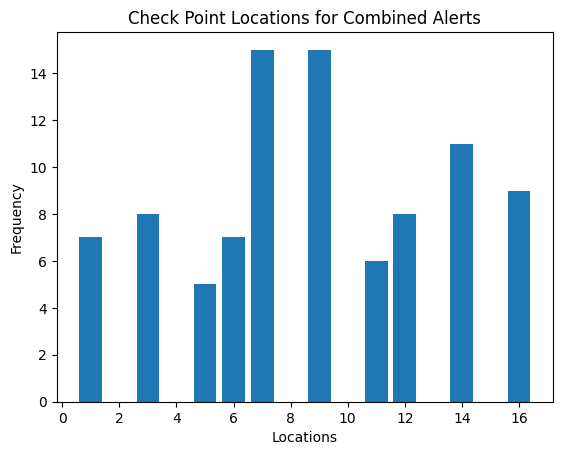

In [317]:
plt.bar(area4.index, area4.values)

plt.xlabel("Locations")
plt.ylabel("Frequency")
plt.title("Check Point Locations for Combined Alerts")

plt.show()